In [2]:
!pip install pennylane
!pip install torchinfo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 59.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 96.8 MB/s eta 0:00:00:00:0100:01


In [3]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datetime import timedelta

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models

from sklearn.metrics import *
from tqdm.auto import tqdm

import pennylane as qml
from torchinfo import summary

# Precision settings
np.set_printoptions(precision=3)
torch.set_printoptions(precision=3)

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 6  
EPOCHS = 10
LR = 0.00005     
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [5]:
CSV_PATH = "/kaggle/input/datasets/farjanakabirsamanta/skin-cancer-dataset/HAM10000_metadata.csv"
IMG_DIR = "/kaggle/input/datasets/farjanakabirsamanta/skin-cancer-dataset/Skin Cancer/Skin Cancer"

In [6]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

In [7]:
class SkinCancerDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

        self.classes = sorted(self.df['dx'].unique())
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.df['label'] = self.df['dx'].map(self.class_to_idx)

        self.image_paths, self.labels = [], []

        for _, row in self.df.iterrows():
            path = os.path.join(self.img_dir, row['image_id'] + ".jpg")
            if os.path.exists(path):
                self.image_paths.append(path)
                self.labels.append(row['label'])

        print(f"Total images: {len(self.image_paths)}")

    def __len__(self): return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

In [8]:
full_dataset = SkinCancerDataset(CSV_PATH, IMG_DIR, transform)

CLASSES = full_dataset.classes
num_classes = len(CLASSES)

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

Total images: 10015


In [9]:
import pennylane as qml
import torch
import torch.nn as nn

n_qubits = 4
n_layers = 2

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):

    # 🔹 DATA ENCODING (Angle Encoding)
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)

    # 🔹 VARIATIONAL LAYERS
    for l in range(n_layers):

        # Rotation layer
        for i in range(n_qubits):
            qml.RX(weights[l, i], wires=i)
            qml.RZ(weights[l, i], wires=i)

        # 🔹 ENTANGLEMENT (chain + ring)
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])
        qml.CNOT(wires=[n_qubits-1, 0])

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


class QuantumLayer(nn.Module):
    def __init__(self, n_qubits=4):
        super().__init__()
        self.n_qubits = n_qubits

        self.weights = nn.Parameter(
            0.01 * torch.randn(n_layers, n_qubits)
        )

    def forward(self, x):
        outputs = []

        for i in range(x.shape[0]):
            q_in = x[i]

            out = quantum_circuit(q_in, self.weights)

            # 🔥 FIX: enforce float32
            out = torch.stack(out).to(torch.float32)

            outputs.append(out)

        return torch.stack(outputs)

In [10]:
class HybridMobileNet(nn.Module):
    def __init__(self, num_classes, n_qubits=4):
        super().__init__()

        base = models.mobilenet_v2(weights="DEFAULT")
        self.features = base.features

        # Freeze 50%
        freeze_layers = len(self.features)//2
        for i in range(freeze_layers):
            for p in self.features[i].parameters():
                p.requires_grad = False

        # ======================
        # ⚛️ Quantum branch
        # ======================
        self.q_branch = nn.Sequential(
            nn.Conv2d(160, 40, 1),
            nn.BatchNorm2d(40),
            nn.ReLU(),

            nn.Conv2d(40, 8, 3, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1,1))
        )

        # 🔥 CHANGE: output → 4 qubits
        self.q_fc = nn.Linear(8, n_qubits)
        self.quantum = QuantumLayer(n_qubits)

        # ======================
        # 🧠 Classical branch
        # ======================
        self.extra = nn.Sequential(
            nn.Conv2d(1280,128,1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        
            # 🔥 CHANGE: 64 → 128
            nn.Conv2d(128,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        
        # 🔥 IMPORTANT: update final FC input
        self.final_fc = nn.Linear(128 + n_qubits, num_classes)

    def forward(self,x):
        # Shared backbone (up to layer 17)
        x = self.features[:17](x)

        # ======================
        # ⚛️ Quantum branch
        # ======================
        q = self.q_branch(x)             # (B, 8, 1, 1)
        q = torch.flatten(q,1)           # (B, 8)
        q = torch.tanh(self.q_fc(q))     # (B, 4)
        q = self.quantum(q)              # (B, 4)

        # ======================
        # 🧠 Classical branch
        # ======================
        c = self.features[17:](x)        # (B, 1280, 7, 7)
        c = self.extra(c)                # (B, 96, 7, 7)
        c = nn.functional.adaptive_avg_pool2d(c,(1,1))
        c = torch.flatten(c,1)           # (B, 96)

        # ======================
        # 🔗 Fusion
        # ======================
        out = torch.cat([c,q],dim=1)     # (B, 100)
        return self.final_fc(out)        # (B, num_classes)

In [11]:
model = HybridMobileNet(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 118MB/s] 


In [12]:
def custom_metrics(y_pred, y_true, loss):
    y_pred = torch.argmax(y_pred,1)

    y_true = y_true.cpu().numpy()
    y_pred = y_pred.cpu().numpy()

    return {
        "loss": round(loss,3),
        "accuracy": round(accuracy_score(y_true,y_pred),3)
    }

In [13]:
train_hist = {"loss":[],"accuracy":[]}
val_hist = {"loss":[],"accuracy":[]}

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    model.train()
    train_loss=0
    preds, labels = [],[]

    for x,y in tqdm(train_loader):
        x,y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out,y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds.append(out)
        labels.append(y)

    preds = torch.cat(preds)
    labels = torch.cat(labels)

    train_metrics = custom_metrics(preds,labels,train_loss/len(train_loader))
    train_hist["loss"].append(train_metrics["loss"])
    train_hist["accuracy"].append(train_metrics["accuracy"])

    print("Train:", {k:f"{v:.3f}" for k,v in train_metrics.items()})

    # VALIDATION
    model.eval()
    val_loss=0
    preds, labels = [],[]

    with torch.no_grad():
        for x,y in val_loader:
            x,y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out,y)

            val_loss += loss.item()
            preds.append(out)
            labels.append(y)

    preds = torch.cat(preds)
    labels = torch.cat(labels)

    val_metrics = custom_metrics(preds,labels,val_loss/len(val_loader))
    val_hist["loss"].append(val_metrics["loss"])
    val_hist["accuracy"].append(val_metrics["accuracy"])

    print("Val:", {k:f"{v:.3f}" for k,v in val_metrics.items()})


Epoch 1/10


  0%|          | 0/1169 [00:00<?, ?it/s]

Train: {'loss': '1.029', 'accuracy': '0.675'}
Val: {'loss': '0.666', 'accuracy': '0.756'}

Epoch 2/10


  0%|          | 0/1169 [00:00<?, ?it/s]

Train: {'loss': '0.722', 'accuracy': '0.753'}
Val: {'loss': '0.569', 'accuracy': '0.800'}

Epoch 3/10


...

Train: {'loss': '0.302', 'accuracy': '0.907'}
Val: {'loss': '0.507', 'accuracy': '0.834'}

Epoch 9/10


  0%|          | 0/1169 [00:00<?, ?it/s]

Train: {'loss': '0.264', 'accuracy': '0.919'}
Val: {'loss': '0.569', 'accuracy': '0.837'}

Epoch 10/10


  0%|          | 0/1169 [00:00<?, ?it/s]

Train: {'loss': '0.234', 'accuracy': '0.930'}
Val: {'loss': '0.578', 'accuracy': '0.827'}


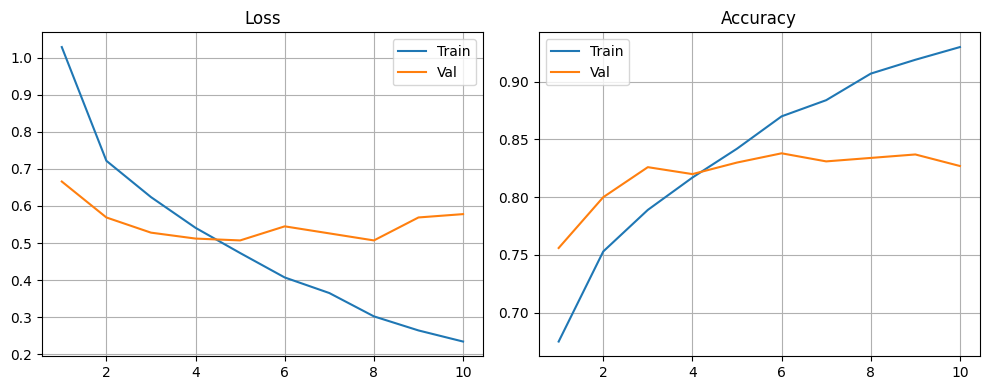

In [14]:
epochs = range(1,len(train_hist["loss"])+1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(epochs,train_hist["loss"],label="Train")
plt.plot(epochs,val_hist["loss"],label="Val")
plt.title("Loss")
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(epochs,train_hist["accuracy"],label="Train")
plt.plot(epochs,val_hist["accuracy"],label="Val")
plt.title("Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [15]:
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)

        all_preds.append(out)
        all_labels.append(y)

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

pred_classes = torch.argmax(all_preds, dim=1)

# Classification Report (3 decimal precision)
report = classification_report(
    all_labels.cpu(),
    pred_classes.cpu(),
    target_names=CLASSES,
    digits=3
)

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(report)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

       akiec      0.593     0.625     0.609        56
         bcc      0.646     0.646     0.646        79
         bkl      0.730     0.633     0.678       158
          df      0.857     0.600     0.706        20
         mel      0.677     0.387     0.492       163
          nv      0.879     0.954     0.915      1008
        vasc      0.654     0.895     0.756        19

    accuracy                          0.825      1503
   macro avg      0.719     0.677     0.686      1503
weighted avg      0.815     0.825     0.814      1503



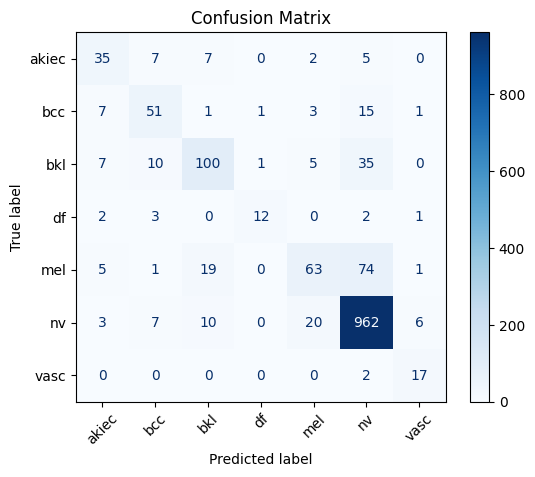

In [16]:
cm = confusion_matrix(all_labels.cpu(), pred_classes.cpu())

disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)
disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix")
plt.show()

In [17]:
#per class accuracy
cm = confusion_matrix(all_labels.cpu(), pred_classes.cpu())

class_acc = cm.diagonal() / cm.sum(axis=1)

print("\nPer-Class Accuracy:\n")
for i, acc in enumerate(class_acc):
    print(f"{CLASSES[i]:<15} : {acc:.3f}")


Per-Class Accuracy:

akiec           : 0.625
bcc             : 0.646
bkl             : 0.633
df              : 0.600
mel             : 0.387
nv              : 0.954
vasc            : 0.895


In [18]:
from graphviz import Digraph

dot = Digraph(format='svg')
dot.attr(rankdir='LR')

# Input
dot.node('Input', 'Input\n[3×224×224]')

# Backbone
dot.node('B1', 'MobileNetV2\n(First 50% Frozen)\n→ [160×7×7]')
dot.edge('Input', 'B1')

# Split
dot.node('Split', 'Split\n[160×7×7]')
dot.edge('B1', 'Split')

# Classical branch
dot.node('C1', 'Remaining MobileNetV2\n→ [1280×7×7]')
dot.node('C2', '1×1 Conv + BN\n→ [128×7×7]')
dot.node('C3', '3×3 Conv + BN\n→ [64×7×7]')
dot.node('C4', 'GAP → Flatten\n→ [64]')

dot.edge('Split', 'C1')
dot.edge('C1', 'C2')
dot.edge('C2', 'C3')
dot.edge('C3', 'C4')

# Quantum branch
dot.node('Q1', '1×1 Conv + BN\n→ [40×7×7]')
dot.node('Q2', '3×3 Conv + BN\n→ [8×7×7]')
dot.node('Q3', 'Pool → Flatten\n→ [8]')
dot.node('Q4', 'Linear → [8]')
dot.node('Q5', 'Quantum Layer\n(8 qubits)')

dot.edge('Split', 'Q1')
dot.edge('Q1', 'Q2')
dot.edge('Q2', 'Q3')
dot.edge('Q3', 'Q4')
dot.edge('Q4', 'Q5')

# Fusion
dot.node('F', 'Concat [64+8=72]')
dot.node('Out', 'Final FC\n→ Classes')

dot.edge('C4', 'F')
dot.edge('Q5', 'F')
dot.edge('F', 'Out')

dot.render('final_architecture', cleanup=True)

print("✅ SVG saved as final_architecture.svg")

✅ SVG saved as final_architecture.svg


In [19]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print("\n" + "="*40)
print(f"{'Total Parameters:':<25} {total_params:,}")
print(f"{'Trainable Parameters:':<25} {trainable_params:,}")
print(f"{'Frozen Parameters:':<25} {frozen_params:,}")
print("="*40)


Total Parameters:         2,546,335
Trainable Parameters:     2,415,519
Frozen Parameters:        130,816
